In [1]:
import spatialdata as sd
import spatialdata_plot
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage import io

/home/stefano/miniconda3/envs/analysis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path = "/home/stefano/Documents/Spatial-Transcriptomic/data/blocco1_sham"
sdata = sd.read_zarr(data_path)
sdata

/tmp/ipykernel_47140/1828072172.py:2: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(data_path)
/home/stefano/miniconda3/envs/analysis/lib/python3.11/site-packages/zarr/core/group.py:3535: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


SpatialData object, with associated Zarr store: /home/stefano/Documents/Spatial-Transcriptomic/data/blocco1_sham
├── Images
│     ├── 'blocco1_hires_image': DataArray[cyx] (3, 1849, 4270)
│     ├── 'blocco1_lowres_image': DataArray[cyx] (3, 185, 427)
│     └── 'fluo_image': DataTree[cyx] (3, 7000, 16166), (3, 3500, 8083), (3, 1750, 4041), (3, 875, 2020)
├── Shapes
│     ├── 'GFP_poly': GeoDataFrame shape: (2, 5) (2D shapes)
│     ├── 'blocco1_square_008um': GeoDataFrame shape: (171116, 2) (2D shapes)
│     ├── 'blocco1_square_016um': GeoDataFrame shape: (44363, 1) (2D shapes)
│     ├── 'intissue_008um': GeoDataFrame shape: (95232, 3) (2D shapes)
│     └── 'intissue_poly': GeoDataFrame shape: (1, 5) (2D shapes)
└── Tables
      ├── 'filtered': AnnData (95232, 32285)
      ├── 'final_table': AnnData (95514, 32285)
      ├── 'square_008um': AnnData (95514, 32285)
      └── 'square_016um': AnnData (44363, 32285)
with coordinate systems:
    ▸ 'blocco1', with elements:
        blocco1_hires

In [3]:
sdata["blocco1_hires_image"]

<xarray.DataArray 'image' (c: 3, y: 1849, x: 4270)> Size: 24MB
dask.array<from-zarr, shape=(3, 1849, 4270), dtype=uint8, chunksize=(3, 1849, 4270), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) <U1 12B 'r' 'g' 'b'
  * y        (y) float64 15kB 0.5 1.5 2.5 3.5 ... 1.846e+03 1.848e+03 1.848e+03
  * x        (x) float64 34kB 0.5 1.5 2.5 3.5 ... 4.268e+03 4.268e+03 4.27e+03
Attributes:
    transform:  {'blocco1_downscaled_hires': Sequence \n    Translation (c, y...

In [5]:
#Crop the image in order to have less computational costs
#for the y axis we need to add 8000 because in spatial data that axis start from this number while in napari it start from 0, 
#for the x axis we can keep the same values since they are the same in both coordinate systems
#y_coords = coords[:,1] +  8000.52221109
#x_coords = coords[:,2]
y_coords = np.array([3.50144653e+03, 3.50144653e+03,1.45220002e+03, 1.45220002e+03]) +  8000.52221109
x_coords = np.array([8.78845536e+03, 6.00671224e+03, 8.78845536e+03, 6.00671224e+03])
y_min, y_max = int(y_coords.min()), int(y_coords.max())
x_min, x_max = int(x_coords.min()), int(x_coords.max())

In [6]:
#crop the data using the bounding box defined by the selected shape
sdata_cropped = sdata.query.bounding_box(
    min_coordinate=[x_min, y_min],
    max_coordinate=[x_max, y_max],
    axes=("x","y"),
    target_coordinate_system='blocco1',
    filter_table=True
)


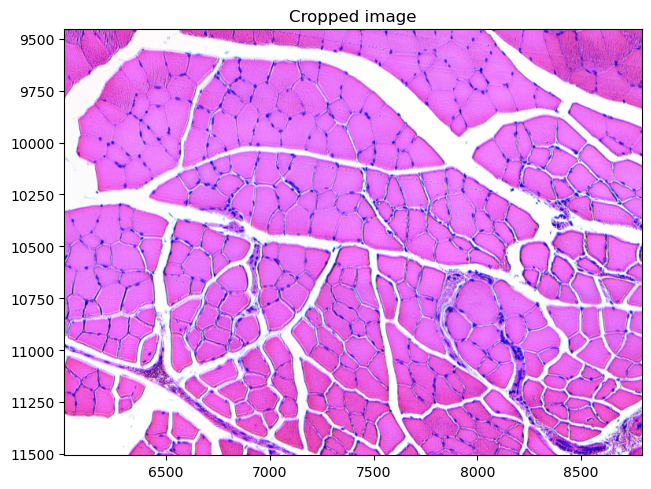

In [7]:
#show the cropped data
sdata_cropped.pl.render_images("blocco1_hires_image").pl.show(coordinate_systems = "blocco1", title="Cropped image")

In [9]:
sdata_cropped

SpatialData object
├── Images
│     ├── 'blocco1_hires_image': DataArray[cyx] (3, 542, 735)
│     ├── 'blocco1_lowres_image': DataArray[cyx] (3, 54, 73)
│     └── 'fluo_image': DataTree[cyx] (3, 2049, 2782), (3, 1025, 1391), (3, 512, 696), (3, 257, 348)
├── Shapes
│     ├── 'blocco1_square_008um': GeoDataFrame shape: (9076, 2) (2D shapes)
│     ├── 'blocco1_square_016um': GeoDataFrame shape: (2321, 1) (2D shapes)
│     ├── 'intissue_008um': GeoDataFrame shape: (9076, 3) (2D shapes)
│     └── 'intissue_poly': GeoDataFrame shape: (1, 5) (2D shapes)
└── Tables
      ├── 'filtered': AnnData (9076, 32285)
      ├── 'final_table': AnnData (9076, 32285)
      ├── 'square_008um': AnnData (9076, 32285)
      └── 'square_016um': AnnData (2321, 32285)
with coordinate systems:
    ▸ 'blocco1', with elements:
        blocco1_hires_image (Images), blocco1_lowres_image (Images), fluo_image (Images), blocco1_square_008um (Shapes), blocco1_square_016um (Shapes), intissue_008um (Shapes), intissue_poly (

In [10]:
#Try to export the cropped image in a tif file suitable for the cellpose segmentation
img = sdata_cropped['blocco1_hires_image'].data.compute()
print(img.shape)
#per dare l'immagine con input corretto a cellpose
# Sposta l'asse 0 (i canali) alla fine (posizione 2)
# L'ordine diventa: (Asse 1, Asse 2, Asse 0) -> (542, 735, 3)
img_fixed = np.transpose(img, (1, 2, 0))

print(img_fixed.shape) 
# Output dovrebbe essere: (542, 735, 3)

(3, 542, 735)
(542, 735, 3)


In [13]:
out_path = os.path.join("/home/stefano/Documents/Spatial-Transcriptomic/images", "sdata_cropped_try.tif")
#save
io.imsave(out_path,img_fixed, check_contrast=False, compression='zlib')

/tmp/ipykernel_27968/589511318.py:3: FutureWarning: The plugin infrastructure in `skimage.io` is deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not pass additional keyword arguments for plugins (`**plugin_args`). Instead, use `imageio` or other I/O packages directly. See also `skimage.io.imsave`.
  io.imsave(out_path,img_fixed, check_contrast=False, compression='zlib')


In [4]:
#Save the full image
img = sdata['blocco1_hires_image'].data.compute()
print(img.shape)
#per dare l'immagine con input corretto a cellpose
# Sposta l'asse 0 (i canali) alla fine (posizione 2)
# L'ordine diventa: (Asse 1, Asse 2, Asse 0) -> (542, 735, 3)
img_fixed = np.transpose(img, (1, 2, 0))

print(img_fixed.shape) 
# Output dovrebbe essere: (542, 735, 3)

(3, 1849, 4270)
(1849, 4270, 3)


In [6]:
out_path = os.path.join("/home/stefano/Documents/Spatial-Transcriptomic/images", "sham1_full.tif")
#save
io.imsave(out_path,img_fixed, check_contrast=False, compression='zlib')

/tmp/ipykernel_6295/2855317689.py:3: FutureWarning: The plugin infrastructure in `skimage.io` is deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not pass additional keyword arguments for plugins (`**plugin_args`). Instead, use `imageio` or other I/O packages directly. See also `skimage.io.imsave`.
  io.imsave(out_path,img_fixed, check_contrast=False, compression='zlib')
